In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa: F401

import segtraq

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
st_segger_with_sc = segtraq.SegTraQ(
    sd.read_zarr("/home/davids/main/projects/Segger_final/segger_output/with_SC_reference/33156-Slide-22_D1-1/segger_spatialdata.zarr"),
    images_key=None,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    points_background_id=None,
    nucleus_shapes_key=None,
)

st_segger_no_sc = segtraq.SegTraQ(
    sd.read_zarr("/home/davids/main/projects/Segger_final/segger_output/no_SC_reference/33156-Slide-22_D1-1/segger_spatialdata.zarr"),
    images_key=None,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    points_background_id=None,
    nucleus_shapes_key=None,
)

st_raw = segtraq.SegTraQ(
    sd.read_zarr("/home/davids/main/projects/Segger_final/input_for_segger/33156-Slide-22_D1-1/raw_spatialdata.zarr"),
    images_key=None,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    points_background_id=None,
    nucleus_shapes_key=None,
)

st_proseg = segtraq.SegTraQ(
    sd.read_zarr("/home/davids/main/projects/proseg/no_SC33156-Slide-1_B1-2/proseg-output.zarr"),
    images_key=None,
    tables_area_key=None,
    points_cell_id_key="assignment",
    points_gene_key="gene",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    tables_cell_id_key="cell",
    points_background_id=None,
    nucleus_shapes_key=None,
)

st_dict = {"segger_with_sc": st_segger_with_sc, "segger_no_sc": st_segger_no_sc, "raw": st_raw, "proseg": st_proseg}

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/segtraq/SegTraQ.py:116: UserWarning: Missing 27716 cell IDs in tables: ['2497.5821529745044', '10497.361747243427', '3253.807603686636', '2442.3453389830506', '11254.251000800641']... These cells are present in shapes, but not in tables. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/segtraq/SegTraQ.py:116: UserWarning: Missing 27716 cell IDs in shapes: ['21605', '17034', '7627', '2

In [36]:
# preprocessing
for st in st_dict.values():
    adata = st.sdata.tables["table"]
    adata.layers["counts"] = adata.X.copy()
    # normalizing and log-transforming the counts
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    # computing a PCA and neighbors
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


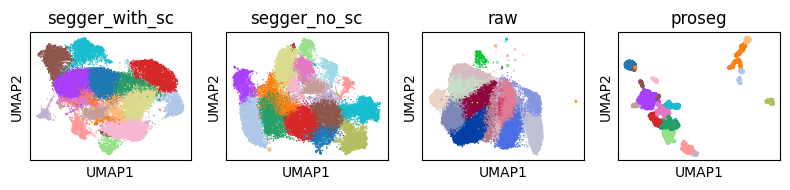

In [37]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2))

# Flatten axs in case of single row/column
axs = axs.flatten()

for i, (method, st) in enumerate(st_dict.items()):
    # here, we do not want to alter the original data, so we create a deep copy
    sdata = st.sdata
    adata = sd.deepcopy(sdata.tables["table"])
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

    sc.pl.umap(
        adata,
        color="leiden",
        ax=axs[i],
        show=False,
        title=method,
        legend_loc=None,
    )

plt.tight_layout()
plt.show()

The cluster connectedness (CC) is a measure that looks at the compactness of clusters.

In [38]:
ccs = {}
for method, st in st_dict.items():
    ccs[method] = st.cs.cluster_connectedness(use_weights=True)
ccs

{'segger_with_sc': 0.9101978316464541,
 'segger_no_sc': 0.9150336534892253,
 'raw': 0.8786113527414602,
 'proseg': 0.9651237058231628}

Values range from −1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

In [39]:
silhouette_scores = {}
for method, st in st_dict.items():
    silhouette_scores[method] = st.cs.silhouette_score()
silhouette_scores

{'segger_with_sc': -0.009535355493426323,
 'segger_no_sc': -0.03173679858446121,
 'raw': -0.05013133957982063,
 'proseg': -0.021544888615608215}

cluster only on a subset of all cells. For example, if we randomly select 63% (
1 −𝑒−1
) of cells and then perform Leiden clustering on those, will our cells typically get assigned to the same cluster or to different ones?

In [40]:
purities = {}
for method, st in st_dict.items():
    purities[method] = st.cs.purity()
purities

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/hom

{'segger_with_sc': 0.8664587901843248,
 'segger_no_sc': 0.832075411208488,
 'raw': 0.8010209988419336,
 'proseg': 0.8697155595555408}

In [41]:
aris = {}
for method, st in st_dict.items():
    aris[method] = st.cs.adjusted_rand_index()
aris

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/hom

{'segger_with_sc': 0.767014712335164,
 'segger_no_sc': 0.7065492849519683,
 'raw': 0.6471766310369845,
 'proseg': 0.7752238413719181}

Seems as if Proseg performs overall somewhat better than segger, BUT first of all it was way slower. Secodn of all, it undersegments like hell, that is why results in simple numbers like these make sense, but one needs to check visualy to see the full vsatnes of Prosegs destruction

label transfer from an scRNA-seq dataset

In [ ]:
# Running label transfer from an scRNA-seq dataset
scRNAseq_data_path = Path("/home/davids/main/sds/sd22c003/guest/heart/heart_snseq/processed_adata_objects/adata_celltyping.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)
st = segtraq.SegTraQ(
    sd.read_zarr("/home/davids/main/projects/Segger_final/segger_output/no_SC_reference/33156-Slide-22_D1-1/segger_spatialdata.zarr"),
    images_key=None,
    tables_area_key=None,
    points_background_id=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    nucleus_shapes_key=None,
)
st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_ensemble_key=None, query_ensemble_key=None)
sc.pp.pca(st.sdata.tables["table"])
sc.pp.neighbors(st.sdata.tables["table"])

In [ ]:
st.cs.cluster_connectedness(cell_type_key="transferred_cell_type")

In [ ]:
st.cs.silhouette_score(cell_type_key="transferred_cell_type")